## Cell 1 — Install dependencies

In [4]:
!pip -q install autogluon.tabular matplotlib scikit-learn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 115.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.5 MB/s eta 0:00:00


## Cell 2 — Import libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from autogluon.tabular import TabularPredictor

## Cell 3 — Load the dataset and redefine the target

In [6]:
# Load the breast cancer dataset from sklearn
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

# Original sklearn target:
# 0 = malignant
# 1 = benign
# For this assignment, set malignant as the positive class (1),
# because detecting malignant cases is the higher-priority outcome.
df["label"] = (df["target"] == 0).astype(int)
df = df.drop(columns=["target"])

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts())
print("\nPositive class ratio (malignant = 1):")
print(df["label"].mean())

df.head()

Dataset shape: (569, 31)

Class distribution:
label
0    357
1    212
Name: count, dtype: int64

Positive class ratio (malignant = 1):
0.37258347978910367


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## Cell 4 — Split into training and test sets

In [7]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

X_test = test_df.drop(columns=["label"])
y_test = test_df["label"].copy()

Training set shape: (455, 31)
Test set shape: (114, 31)


## Cell 5 — Define economic assumptions

In [8]:
# Business / economic assumptions for threshold selection
TP_VALUE = 50000    # Value of correctly identifying a malignant case
FP_COST  = 1500     # Cost of a false positive (extra testing, anxiety, follow-up)
FN_COST  = 100000   # Cost of a false negative (missed malignant case)
TN_VALUE = 0        # No direct additional gain assigned to true negatives

print("Economic assumptions:")
print(f"TP_VALUE = {TP_VALUE}")
print(f"FP_COST  = {FP_COST}")
print(f"FN_COST  = {FN_COST}")
print(f"TN_VALUE = {TN_VALUE}")

Economic assumptions:
TP_VALUE = 50000
FP_COST  = 1500
FN_COST  = 100000
TN_VALUE = 0


## Cell 6 — Train the AutoML model

In [9]:
predictor = TabularPredictor(
    label="label",
    problem_type="binary",
    path="AutogluonModels_breast_cancer"
).fit(
    train_data=train_df,
    presets="best_quality",
    time_limit=300
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.10.0+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       10.99 GB / 12.67 GB (86.7%)
Disk Space Avail:   69.11 GB / 112.64 GB (61.4%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacke

## Cell 7 — View the model leaderboard

In [10]:
leaderboard = predictor.leaderboard(test_df, silent=True)
leaderboard

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetTorch_r22_BAG_L1,0.991228,0.989011,accuracy,0.132777,0.144164,12.408396,0.132777,0.144164,12.408396,1,True,15
1,NeuralNetTorch_r79_BAG_L1,0.991228,0.993407,accuracy,0.154970,0.157166,15.046810,0.154970,0.157166,15.046810,1,True,11
2,WeightedEnsemble_L2,0.991228,0.993407,accuracy,0.157036,0.157952,15.119363,0.002066,0.000786,0.072553,2,True,27
3,WeightedEnsemble_L3,0.991228,0.993407,accuracy,0.157170,0.158040,15.115103,0.002200,0.000874,0.068294,3,True,46
4,NeuralNetTorch_r30_BAG_L1,0.991228,0.993407,accuracy,0.160702,0.140394,17.556309,0.160702,0.140394,17.556309,1,True,23
5,XGBoost_BAG_L2,0.991228,0.989011,accuracy,0.523875,0.473536,31.315208,0.053709,0.019922,1.398360,2,True,35
6,RandomForestEntr_BAG_L2,0.991228,0.989011,accuracy,0.543456,0.560107,30.618428,0.073290,0.106493,0.701580,2,True,31
7,ExtraTrees_r42_BAG_L2,0.991228,0.984615,accuracy,0.546406,0.558534,30.531486,0.076239,0.104920,0.614638,2,True,44
8,NeuralNetFastAI_r191_BAG_L2,0.991228,0.991209,accuracy,0.552118,0.503618,35.171231,0.081951,0.050004,5.254383,2,True,40
9,RandomForestGini_BAG_L2,0.991228,0.989011,accuracy,0.554774,0.558254,30.575987,0.084607,0.104640,0.659139,2,True,30


## Cell 8 — Generate predicted probabilities and compute Average Precision

In [11]:
# Get predicted probabilities
proba_df = predictor.predict_proba(X_test)

# Use the probability for the positive class (label = 1)
if 1 in proba_df.columns:
    y_score = proba_df[1].values
else:
    y_score = proba_df.iloc[:, 1].values

ap_score = average_precision_score(y_test, y_score)

print("Average Precision (AP):", round(ap_score, 4))

Average Precision (AP): 0.9947


## Cell 9 — Plot the Precision-Recall curve

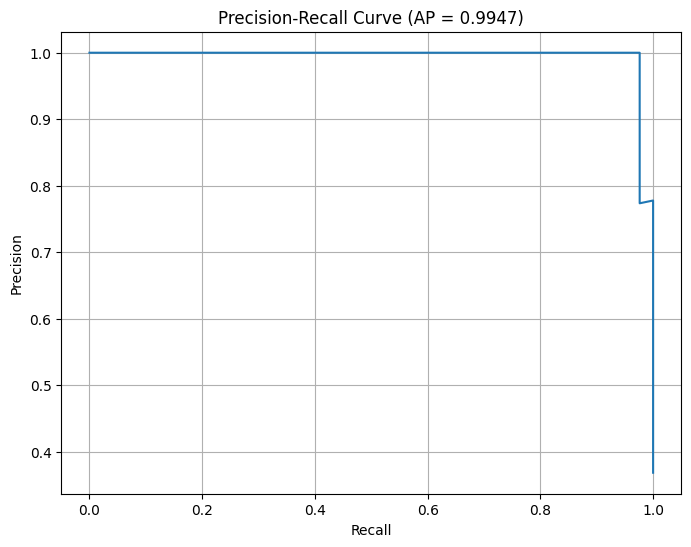

In [12]:
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {ap_score:.4f})")
plt.grid(True)
plt.show()

## Cell 10 — Create a function to evaluate threshold performance

In [13]:
def evaluate_threshold(y_true, y_prob, threshold,
                       tp_value=TP_VALUE,
                       fp_cost=FP_COST,
                       fn_cost=FN_COST,
                       tn_value=TN_VALUE):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_val = (2 * precision_val * recall_val / (precision_val + recall_val)
              if (precision_val + recall_val) > 0 else 0)

    net_value = (
        tp * tp_value
        + tn * tn_value
        - fp * fp_cost
        - fn * fn_cost
    )

    return {
        "threshold": threshold,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision": precision_val,
        "recall": recall_val,
        "f1": f1_val,
        "net_value": net_value
    }

## Cell 11 — Test multiple thresholds

In [14]:
threshold_grid = np.round(np.arange(0.01, 1.00, 0.01), 2)

results = []
for t in threshold_grid:
    results.append(evaluate_threshold(y_test, y_score, t))

threshold_results = pd.DataFrame(results)

threshold_results.head()

,threshold,tp,fp,fn,tn,precision,recall,f1,net_value
0,0.01,42,18,0,54,0.700000,1.00000,0.823529,2073000
1,0.02,42,16,0,56,0.724138,1.00000,0.840000,2076000
2,0.03,42,12,0,60,0.777778,1.00000,0.875000,2082000
3,0.04,41,12,1,60,0.773585,0.97619,0.863158,1932000
4,0.05,41,12,1,60,0.773585,0.97619,0.863158,1932000


## Cell 12 — Select the final threshold

In [15]:
# Business rule:
# First require recall >= 0.95, then choose the threshold
# with the highest net business value.
candidate_results = threshold_results[threshold_results["recall"] >= 0.95].copy()

if len(candidate_results) > 0:
    best_row = candidate_results.sort_values(
        by=["net_value", "precision"],
        ascending=[False, False]
    ).iloc[0]
else:
    # Fallback: if no threshold reaches recall >= 0.95,
    # choose the threshold with the highest net value
    best_row = threshold_results.sort_values(
        by=["net_value", "precision"],
        ascending=[False, False]
    ).iloc[0]

best_threshold = float(best_row["threshold"])

print("Selected threshold:", best_threshold)
print("\nBest threshold result:")
print(best_row)

Selected threshold: 0.03

Best threshold result:
threshold    3.000000e-02
tp           4.200000e+01
fp           1.200000e+01
fn           0.000000e+00
tn           6.000000e+01
precision    7.777778e-01
recall       1.000000e+00
f1           8.750000e-01
net_value    2.082000e+06
Name: 2, dtype: float64


## Cell 13 — Plot precision, recall, and F1 across thresholds

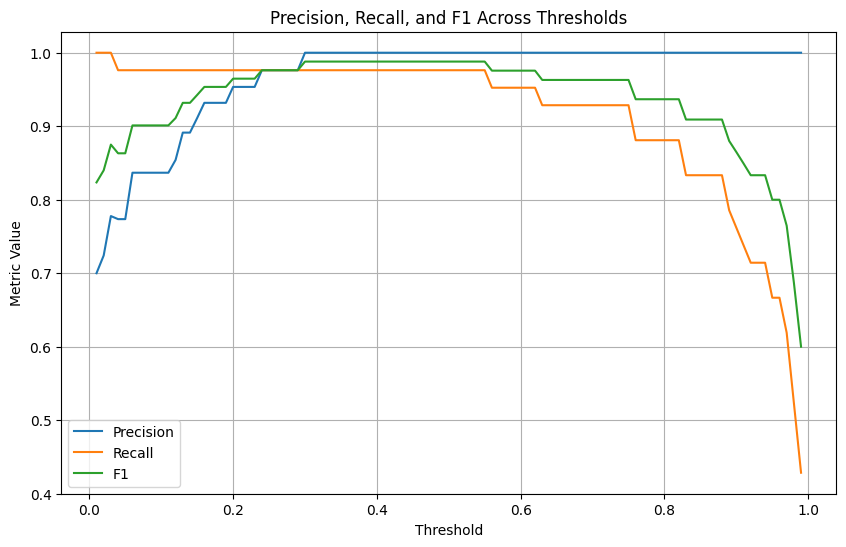

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_results["threshold"], threshold_results["precision"], label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.title("Precision, Recall, and F1 Across Thresholds")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
import os

threshold_results.to_csv("threshold_results.csv", index=False)

print("Current working directory:", os.getcwd())
print("Saved file:", os.path.abspath("threshold_results.csv"))
print("Exists:", os.path.exists("threshold_results.csv"))

!ls -l

Current working directory: /content
Saved file: /content/threshold_results.csv
Exists: True
total 16
drwxr-xr-x 4 root root 4096 Mar 22 19:38 AutogluonModels_breast_cancer
drwxr-xr-x 1 root root 4096 Feb  6 14:31 sample_data
-rw-r--r-- 1 root root 6771 Mar 22 19:42 threshold_results.csv


## Cell 14 — Plot net business value across thresholds

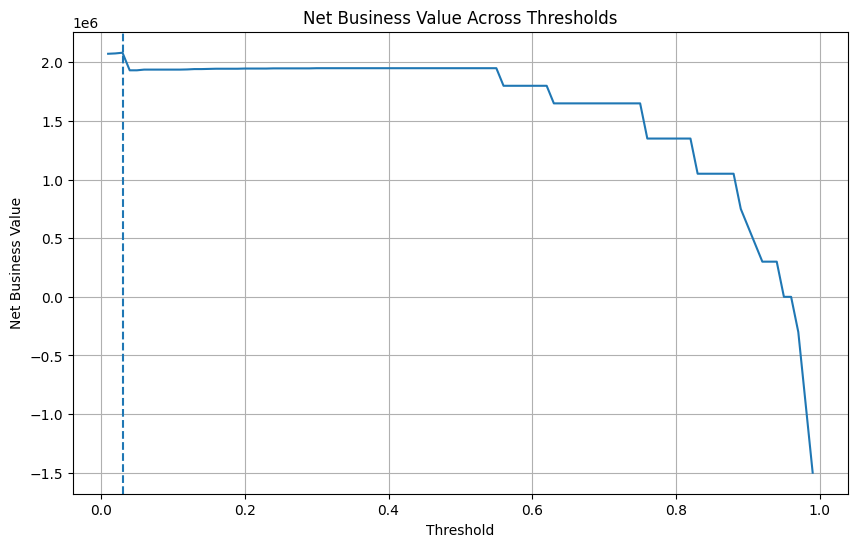

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_results["threshold"], threshold_results["net_value"])
plt.axvline(best_threshold, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("Net Business Value")
plt.title("Net Business Value Across Thresholds")
plt.grid(True)
plt.show()

## Cell 15 — Evaluate the final threshold

In [19]:
final_pred = (y_score >= best_threshold).astype(int)

print("Final threshold:", best_threshold)
print("\nClassification report:")
print(classification_report(
    y_test,
    final_pred,
    target_names=["benign (0)", "malignant (1)"]
))

Final threshold: 0.03

Classification report:
               precision    recall  f1-score   support

   benign (0)       1.00      0.83      0.91        72
malignant (1)       0.78      1.00      0.88        42

     accuracy                           0.89       114
    macro avg       0.89      0.92      0.89       114
 weighted avg       0.92      0.89      0.90       114



## Cell 16 — Display the confusion matrix

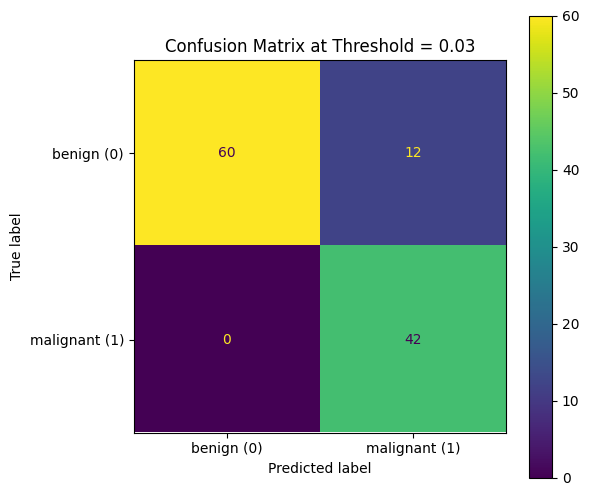

In [20]:
cm = confusion_matrix(y_test, final_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign (0)", "malignant (1)"])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)
plt.title(f"Confusion Matrix at Threshold = {best_threshold}")
plt.show()

## Cell 17 — Print the final metrics for the paper

In [21]:
final_metrics = evaluate_threshold(y_test, y_score, best_threshold)

print("===== Final Metrics for the Paper =====")
for k, v in final_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print(f"\nAverage Precision (AP): {ap_score:.4f}")
print(f"Selected Threshold: {best_threshold:.2f}")

===== Final Metrics for the Paper =====
threshold: 0.0300
tp: 42
fp: 12
fn: 0
tn: 60
precision: 0.7778
recall: 1.0000
f1: 0.8750
net_value: 2082000

Average Precision (AP): 0.9947
Selected Threshold: 0.03


## Cell 18 — Save the threshold results

In [22]:
threshold_results.to_csv("threshold_results.csv", index=False)
print("Saved file: threshold_results.csv")

Saved file: threshold_results.csv
